**Machine Learning Project**


The numerical dataset 1. Student Performance.

In [ ]:
# Import necessary libraries
import numpy as np
#Used for:Working with arrays and numerical data , Fast mathematical operations ,and Linear algebra, statistics, random numbers
import pandas as pd
#Used for:Handling tabular data (datasets) , Reading files (CSV, Excel) ,and Data cleaning and preprocessing
import matplotlib.pyplot as plt
#Used for:Creating basic plots ,and Full control over visualization
import seaborn as sns
#Used for:Statistical data visualization , Built on top of Matplotlib ,and Works very well with Pandas DataFrames

In [ ]:
# Importing the dataset
df= pd.read_csv('Student_Performance.csv') # Reading the data set as a csv file using pandas library

In [ ]:
# Explore the Data
# feature extraction phase
print(df.head())          # First few rows (by default 5 rows)
print(df.columns)         # Column names
print(df.shape)           # Dimensions of the dataset
print(df.info())          # Column types & nulls
print(df.describe())      # Summary stats


   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  
Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')
(10000, 6)
<class 'p

Initial Visualization (Before Preprocessing)

In [ ]:
# Initial Visualization (Before Preprocessing)
num_cols = ["Hours Studied", "Previous Scores", "Extracurricular Activities", " Sleep Hours",
"Sample Question Papers Practiced", "Performance Index"]
#num_cols list contains column names from your dataset that represent numerical features.
#Used for:
#Select numerical columns Apply visualization (histograms, boxplots, etc.) , Apply preprocessing techniques
#like: Normalization / Standardization , and Outlier detection

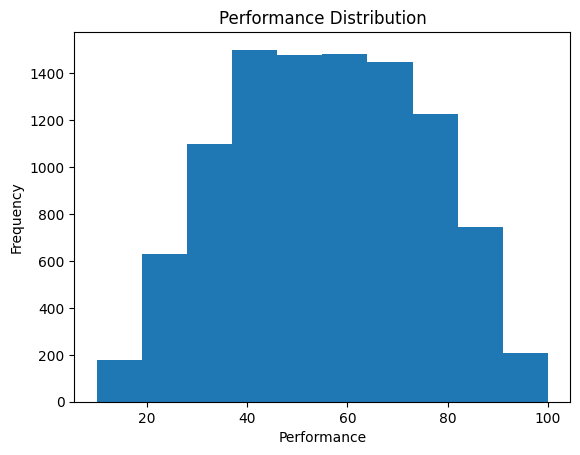

In [ ]:
# Histograms (Before Preprocessing)
# Purpose: To see the distribution of a single variable.
# Check if data is normally distributed or skewed. Helps in deciding transformations
#used for Show data distribution (High-frequency ranges and Low-frequency ranges)
#Detect skewness : Right-skewed → many low values, few high values , Left-skewed → many high values, few low values
#Detect outliers
# Help choose preprocessing steps as -> Standardization vs Normalization

plt.hist(df['Performance Index'], bins=10)  # bins = number of bars
plt.title("Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Frequency")
plt.show()


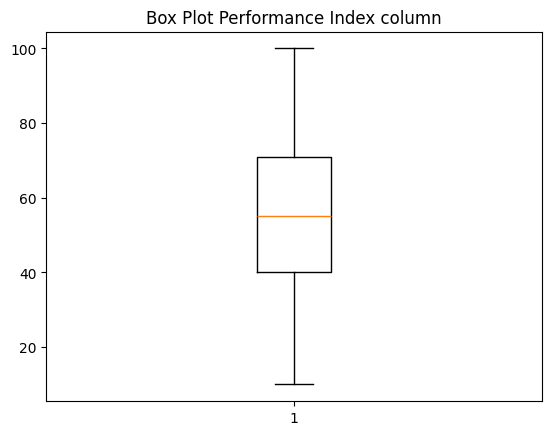

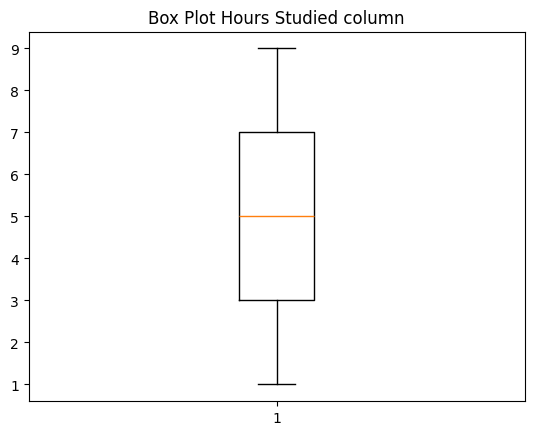

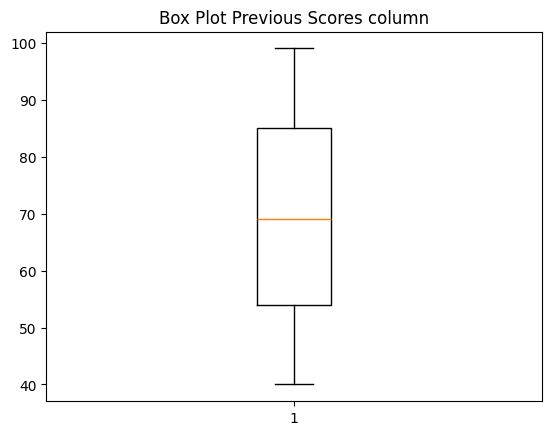

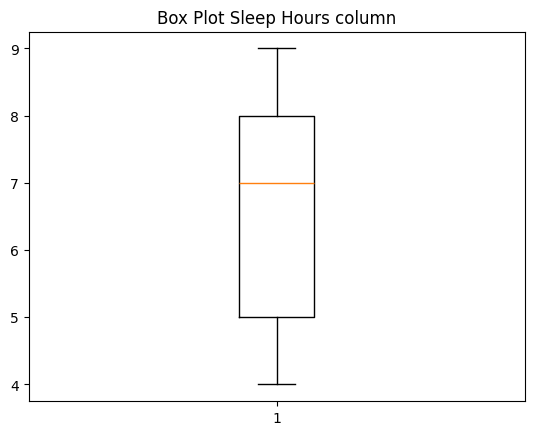

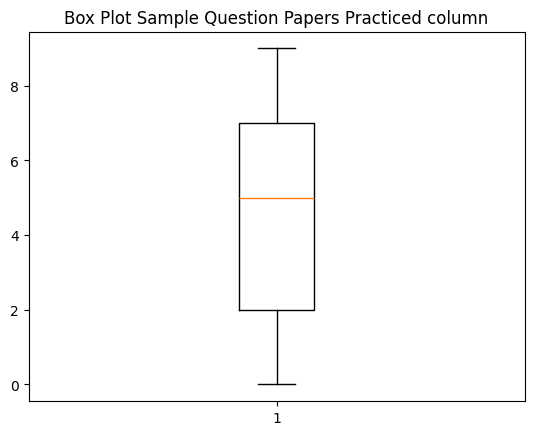

In [ ]:
# Boxplots for each feature and the target predected value
# Purpose: To detect outliers and understand spread/variance.
# Use it on Income to quickly see if there are extreme values that might affect the model.

# Boxplots for Performance Index (target)(predected value)
plt.boxplot(df['Performance Index'])
plt.title("Box Plot Performance Index column")
plt.show()
# Boxplots for Hours Studied (feature)
plt.boxplot(df['Hours Studied'])
plt.title("Box Plot Hours Studied column")
plt.show()
# Boxplots for Previous Scores (feature)
plt.boxplot(df['Previous Scores'])
plt.title("Box Plot Previous Scores column")
plt.show()
# Boxplots for Extracurricular Activities (feature) are not suitable as it's a categorical column.
# We will visualize this feature, consider a countplot (Later)
# Boxplots for Sleep Hours (feature)
plt.boxplot(df['Sleep Hours'])
plt.title("Box Plot Sleep Hours column")
plt.show()
# Boxplots for Sample Question Papers Practiced (feature)
plt.boxplot(df['Sample Question Papers Practiced'])
plt.title("Box Plot Sample Question Papers Practiced column")
plt.show()

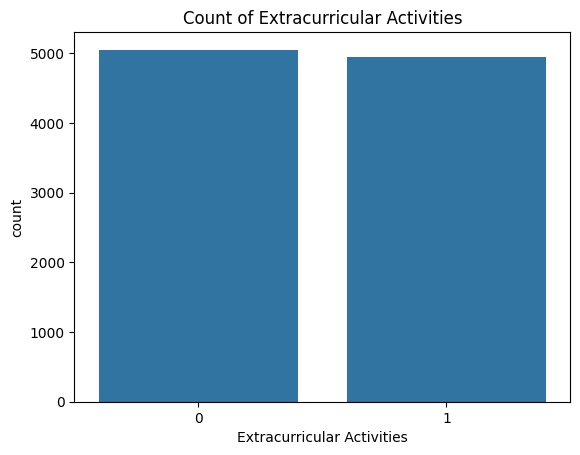

In [ ]:
sns.countplot(x="Extracurricular Activities", data=df)
plt.title("Count of Extracurricular Activities")
plt.show()


# Data pre-processing


In [ ]:
# Data pre-processing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Fill missing values (in case there are missing values)
# Fill numeric columns with mean
# Fill categorical columns with mode
# Remove columns with any missing values

# Removing Duplicate Records
# Detect duplicate rows
duplicates = df[df.duplicated()]
# Remove duplicate rows (keep first occurrence)
df_no_duplicates = df.drop_duplicates()

# 1. Drop unnecessary columns as:Name , identifires (if exist) (in my data there is no exist of un necessary or miss leading columns )
# if 'Name' in df.columns:
#     df = df.drop(columns=['Name'])

# Filter out outliers
# Option 1: Outlier removal using IQR method
# Option 2: Z-score method for outlier detection

# Encode categorical columns
categorical_cols = ['Extracurricular Activities']
le = LabelEncoder() # Apply LabelEncoder to the Series, not a DataFrame with one column
df[categorical_cols[0]] = le.fit_transform(df[categorical_cols[0]].astype(str))
# Separate features and target
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']

# Handle imbalance with SMOTE
# in case there is

In [ ]:
print(df.head())          # First few rows

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 48)

In [ ]:
#     FEATURE SCALING Method1 (MinMax Scaler)
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
X_train_scaled = mm.fit_transform(X_train)
X_test_scaled = mm.transform(X_test)

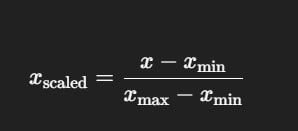

In [ ]:
#     FEATURE SCALING Method2 (Standard Scaler)
std = StandardScaler()
X_train_scaled = std.fit_transform(X_train)
X_test_scaled = std.transform(X_test)

# <img src="https://journaldev.nyc3.digitaloceanspaces.com/2020/10/Standardization.png" width="50%"/>


In [ ]:
# dimension of resulted features.
print("features shape:", X.shape)

features shape: (10000, 5)


# Apply Linear regressors for Regression

In [ ]:
# Define features and target
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']

In [ ]:
# Create and train the model
# Train-test split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
lr = LinearRegression()
# Fit (train) the model on the training data
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)


In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

# Show first 10 actual vs predicted
comparison = pd.DataFrame({
    'Actual ': y_test[:10],
    'Predicted ': y_pred_lr[:10]
})
print("First 10 Actual vs Predicted values:")
print(comparison)


First 10 Actual vs Predicted values:
      Actual   Predicted 
358      62.0   56.866136
8958     35.0   39.532233
1985     50.0   50.851839
1444     75.0   71.423391
1540     31.0   31.556745
6808     43.0   45.093706
9405     58.0   58.105809
749      69.0   69.610742
8668     79.0   82.712053
8253     70.0   66.985891


In [ ]:
# 5-Fold Cross Validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5)

In [ ]:
#Results details:
# For each model you should show all these results for your model on testing data
#     Model Evaluation
#     Linear Regression Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

lr_mse, lr_rmse, lr_mae, lr_r2 = metrics(y_test, y_pred_lr)

print("\n===== Linear Regression Results =====")
print("MSE:", lr_mse)#Mean Squared Error (MSE)
print("RMSE:", lr_rmse)#Root Mean Squared Error (RMSE)
print("MAE:", lr_mae)#Mean Absolute Error (MAE)
print("R2:", lr_r2) #R2=1−(​SSres​​/SStot)
#SSres= Residual Sum of Squares , 𝑆𝑆tot= Total Sum of Squares


===== Linear Regression Results =====
MSE: 4.179189661996083
RMSE: 2.0443066457838666
MAE: 1.6161668670263483
R2: 0.9886027439353303


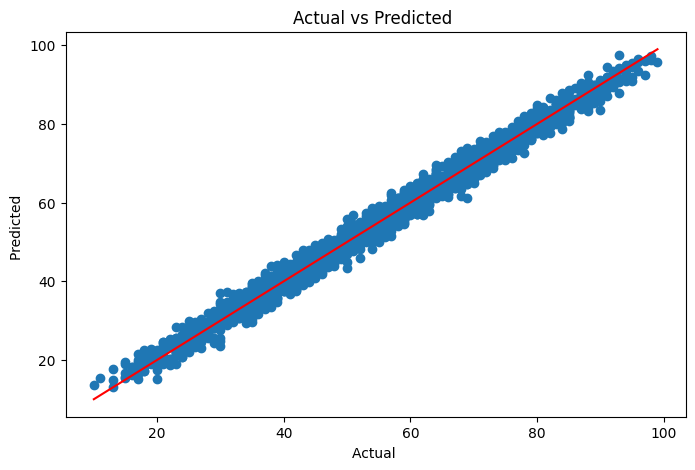

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual ")
plt.ylabel("Predicted ")
plt.title("Actual vs Predicted ")

# Line y = x for reference (perfect prediction)
# Find the smallest value across both actual and predicted MPG
min_val = min(y_test.min(), y_pred_lr.min())
# Find the largest value across both actual and predicted MPG
max_val = max(y_test.max(), y_pred_lr.max())
# Plot a straight line between (min_val, min_val) and (max_val, max_val)
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.show()


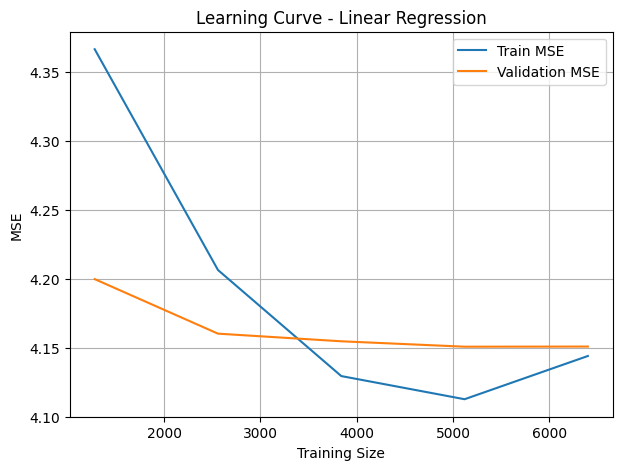

In [ ]:
#          LEARNING CURVES
#plots a Learning Curve for a machine learning model (here: Linear Regression)
#to analyze how the model’s performance changes as the training data size increases.
#Learning curves help us detect: Underfitting , Overfitting

# Import learning_curve
from sklearn.model_selection import learning_curve
#Training sizes
#This creates 5 training sizes: 20% of the data, 40% of the data,
train_sizes = np.linspace(0.2, 1.0, 5)
#Function definition
#Takes a machine learning model
#Takes a plot title
def plot_learning_curve(model, title):
  #Compute learning curves
    train_sizes_lc, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train,
        cv=5, scoring="neg_mean_squared_error",
        train_sizes=train_sizes
    )
#Output:
#train_sizes_lc: number of training samples used
#train_scores: MSE on training data
#val_scores: MSE on validation data

#Convert scores to positive MSE
    train_mse = -train_scores.mean(axis=1)
    val_mse = -val_scores.mean(axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes_lc, train_mse, label="Train MSE")
    plt.plot(train_sizes_lc, val_mse, label="Validation MSE")
    plt.xlabel("Training Size")
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curve(lr, "Learning Curve - Linear Regression")

#Underfitting
#Training MSE and Validation MSE are high and close
#Model is too simple

#Overfitting
#Training MSE is very low
#Validation MSE is high
#Model memorizes training data

#Good fit
#Both errors are low and close
#Model generalizes well

#Our Linear Regression model generalizes well without overfitting or underfitting. El hamd llah

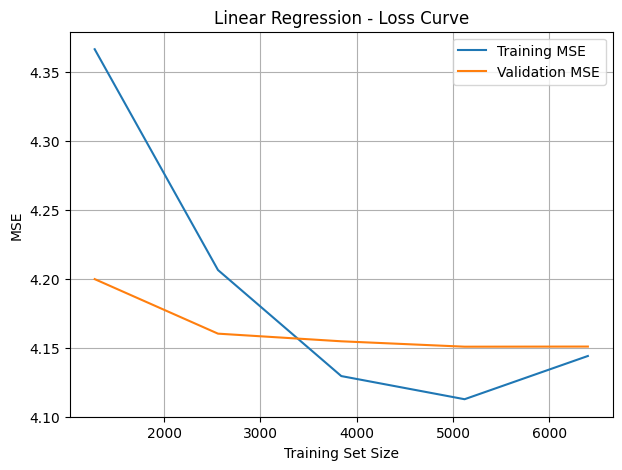

In [ ]:
# Calculate Avg MSE
#plots a Loss Curve for a Linear Regression model using Mean Squared Error (MSE).
#It shows how the training error and validation error change as the training set size increases.

train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

train_sizes_lr, train_scores_lr, val_scores_lr = learning_curve(
    LinearRegression(),
    X_train_scaled, y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=train_sizes
)

train_mse = -train_scores_lr.mean(axis=1)
val_mse = -val_scores_lr.mean(axis=1)

# Drow Loss Curve
plt.figure(figsize=(7,5))
plt.plot(train_sizes_lr, train_mse, label='Training MSE')
plt.plot(train_sizes_lr, val_mse, label='Validation MSE')
plt.xlabel('Training Set Size')
plt.ylabel('MSE')
plt.title('Linear Regression - Loss Curve')
plt.legend()
plt.grid()
plt.show()

# **Apply K-Nearest Neighbors (KNN) for regression**

In [ ]:
# Step 1: Import necessary libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
# Step 3: Use Grid Search to find the best value for k (from 1 to 10)
param_grid = {'n_neighbors': range(1, 11)}  # Try k from 1 to 10
knn = KNeighborsRegressor()
grid_search = GridSearchCV(knn, param_grid, cv=5)  # 5-fold cross-validation
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': range(1, 11)})

In [ ]:
# Step 4: Get the best value of k
best_k = grid_search.best_params_['n_neighbors']
print(f"Best value for k: {best_k}")

Best value for k: 10


In [ ]:
# Step 6: Train KNN with the best k and make predictions
knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(


In [ ]:
# Step 7: Calculate the accuracy
# The accuracy_score metric is not appropriate for regression tasks with continuous targets.
# This cell should be removed or replaced with regression metrics like MSE, RMSE, MAE, or R2.
# These metrics are already calculated for the KNN Regressor (later)

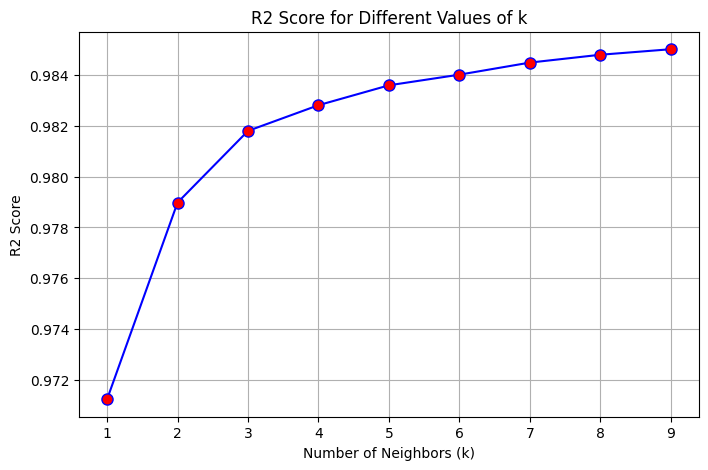

In [ ]:
# Step 8: Visualize the R2 Score for different values of k
from sklearn.metrics import r2_score
k_values = range(1, 10)
r2_scores = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

# Plot the R2 scores for each value of k
plt.figure(figsize=(8, 5))
plt.plot(k_values, r2_scores, marker='o', linestyle='-', color='b', markerfacecolor='r', markersize=8)
plt.title('R2 Score for Different Values of k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('R2 Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [ ]:
#     KNN METRICS
#     Model Evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}
print("===== KNN Regressor Evaluation Metrics =====")
metrics_knn = regression_metrics(y_test, y_pred)
metrics_df = pd.DataFrame([metrics_knn], index=['KNN'])
print(metrics_df)



===== KNN Regressor Evaluation Metrics =====
         MSE      RMSE       MAE        R2
KNN  5.49229  2.343564  1.847056  0.985022


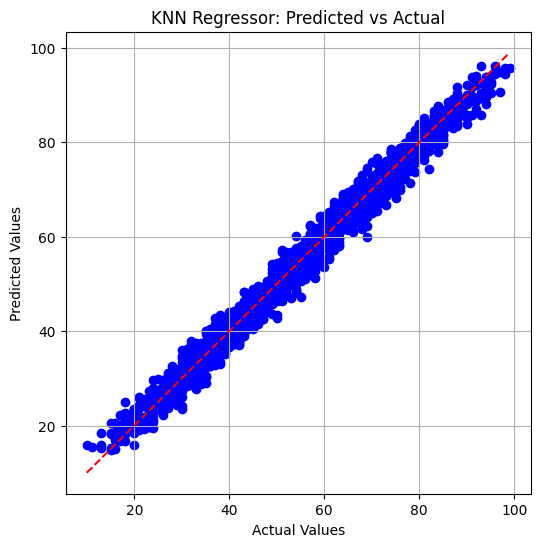

In [ ]:
#       PREDICTED VS ACTUAL PLOT
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("KNN Regressor: Predicted vs Actual")
plt.grid()
plt.show()

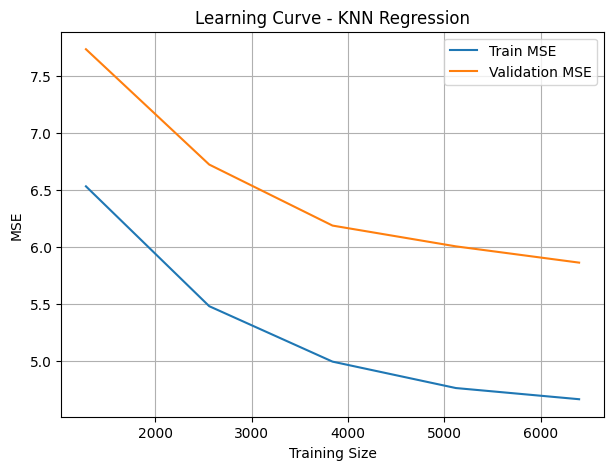

In [ ]:
#          LEARNING CURVES
#plots a Learning Curve for a machine learning model (here: KNN Regression)
#to analyze how the model’s performance changes as the training data size increases.
#Learning curves help us detect: Underfitting , Overfitting

# Import learning_curve
from sklearn.model_selection import learning_curve
#Training sizes
#This creates 5 training sizes: 20% of the data, 40% of the data,
train_sizes = np.linspace(0.2, 1.0, 5)
#Function definition
#Takes a machine learning model
#Takes a plot title
def plot_learning_curve(model, title):
  #Compute learning curves
    train_sizes_lc, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=5, scoring="neg_mean_squared_error",
        train_sizes=train_sizes
    )
#Output:
#train_sizes_lc: number of training samples used
#train_scores: MSE on training data
#val_scores: MSE on validation data

#Convert scores to positive MSE
    train_mse = -train_scores.mean(axis=1)
    val_mse = -val_scores.mean(axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes_lc, train_mse, label="Train MSE")
    plt.plot(train_sizes_lc, val_mse, label="Validation MSE")
    plt.xlabel("Training Size")
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curve(knn, "Learning Curve - KNN Regression")

#Underfitting
#Training MSE and Validation MSE are high and close
#Model is too simple

#Overfitting
#Training MSE is very low
#Validation MSE is high
#Model memorizes training data

#Good fit
#Both errors are low and close
#Model generalizes well

#Our KNN Regression model improves with more data but shows mild overfitting
# as validation error remains higher than training error. El hamd llah
#Generalization is acceptable but not optimal.
#Performance may improve by:
#Increasing k value (more neighbors)

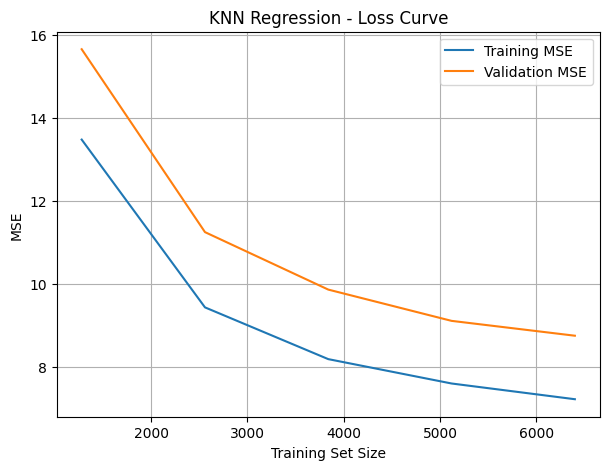

In [ ]:
# Calculate Avg MSE
#plots a Loss Curve for a KNN Regression model using Mean Squared Error (MSE).
#It shows how the training error and validation error change as the training set size increases.

from sklearn.neighbors import KNeighborsRegressor

train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

train_sizes_knn, train_scores_knn, val_scores_knn = learning_curve(
    KNeighborsRegressor(n_neighbors=best_k), # Use KNN Regressor with the best k found
    X_train_scaled, y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    train_sizes=train_sizes
)

train_mse = -train_scores_knn.mean(axis=1)
val_mse = -val_scores_knn.mean(axis=1)

# Draw Loss Curve
plt.figure(figsize=(7,5))
plt.plot(train_sizes_knn, train_mse, label='Training MSE')
plt.plot(train_sizes_knn, val_mse, label='Validation MSE')
plt.xlabel('Training Set Size')
plt.ylabel('MSE')
plt.title('KNN Regression - Loss Curve')
plt.legend()
plt.grid()
plt.show()